In [1]:
# !pip install anomalib
# !pip install matplotlib
# !pip install numpy
# !pip install tensorboard
# !pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu128
# !pip install kaggle

In [1]:
import numpy as np
from PIL import Image
from torchvision import transforms
import torch

In [2]:
# 2. Импорт необходимых модулей
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import json
import random
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim
import torch.nn.functional as torch_f
import torch.nn as nn

from anomalib.models.image.fastflow.loss import FastflowLoss
from anomalib.models.image.fastflow.torch_model import FastflowModel

from sklearn.metrics import confusion_matrix
import cv2
from skimage import data, filters, measure
from skimage.segmentation import clear_border
# import warnings
# warnings.filterwarnings('ignore')

c:\Users\AERO\Desktop\master_work\FastFlow\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import cv2

def check_all_images_grayscale(root_dir):
    """
    Проверяет, что все изображения (.png, .jpg, .jpeg) в указанной папке и подпапках
    являются одноканальными (grayscale).

    :param root_dir: корневая директория датасета
    :return: True, если все изображения одноканальные; иначе False + вывод проблемных файлов.
    """
    extensions = {'.png', '.jpg', '.jpeg'}
    all_ok = True
    problematic = []

    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            if os.path.splitext(f)[1].lower() in extensions:
                path = os.path.join(dirpath, f)
                img = cv2.imread(path, cv2.IMREAD_UNCHANGED)  # Сохраняем исходное количество каналов
                if img is None:
                    print(f"⚠️ Не удалось загрузить изображение: {path}")
                    continue

                if img.ndim == 2:
                    continue
                elif img.ndim == 3 and img.shape[2] == 1:
                    continue
                elif img.ndim == 3 and img.shape[2] == 3:
                    problematic.append((path, img.shape))
                    all_ok = False
                else:
                    problematic.append((path, img.shape))
                    all_ok = False

    if not all_ok:
        print("❌ Найдены цветные или многоканальные изображения:")
        for p, shape in problematic:
            print(f"  - {p} → shape = {shape}")
    else:
        print("✅ Все изображения одноканальные (grayscale).")

    return all_ok

In [48]:
import os
import cv2

def check_all_images_int(root_dir):
    """
    Проверяет, что все изображения (.png, .jpg, .jpeg) в указанной папке и подпапках
    являются одноканальными (grayscale).

    :param root_dir: корневая директория датасета
    :return: True, если все изображения одноканальные; иначе False + вывод проблемных файлов.
    """
    extensions = {'.png', '.jpg', '.jpeg'}
    all_ok = True
    problematic = []
    int8_num = 0
    int16_num = 0
    int16_num_paths = []

    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            if os.path.splitext(f)[1].lower() in extensions:
                path = os.path.join(dirpath, f)
                try:
                    img = Image.open(path)
                except:
                    print(f"⚠️ Не удалось загрузить изображение: {path}")
                    continue

                arr_img = np.array(img)
                if arr_img.dtype == np.uint8:
                    int8_num += 1
                    continue
                elif arr_img.dtype == np.uint16:
                    int16_num += 1
                    int16_num_paths.append(path)
                    continue
                else:
                    problematic.append((path, arr_img.dtype))
                    all_ok = False

    print("uint8: ", int8_num)
    print("uint16: ", int16_num, int16_num_paths)
    if not all_ok:
        print("❌ Не соответствуют заданному типу данных:")
        for p, shape in problematic:
            print(f"  - {p} → shape = {shape}")
    else:
        print("✅ Все изображения np.uint8 или np.uint16.")

    return all_ok

In [ ]:
# check_all_images_grayscale("datasets/3d_printer_dataset")

⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2024-12-16\rect\._105.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2024-12-16\rect\._234.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2024-12-16\rect\._78.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2025-03-21\rect\._184.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2025-05-28\rect\._104.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2025-06-19\rect\._394.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2025-06-19\rect\._399.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2025-06-25\correlation_script_masks\._17.png
❌ Найдены цветные или многоканальные изображения:
  - datasets/3d_printer_dataset\training_data\2024-12-16\rect\.ipynb_checkpoints\104-checkpo

False

In [49]:
check_all_images_int("datasets/3d_printer_dataset")

⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2024-12-16\rect\._105.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2024-12-16\rect\._234.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2024-12-16\rect\._78.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2025-03-21\rect\._184.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2025-05-28\rect\._104.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2025-06-19\rect\._394.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2025-06-19\rect\._399.png
⚠️ Не удалось загрузить изображение: datasets/3d_printer_dataset\training_data\2025-06-25\correlation_script_masks\._17.png
uint8:  6174
uint16:  675 ['datasets/3d_printer_dataset\\anomalous_data\\2025-08-06_11-28-56_L0408_1.png', 'datasets/3d_printer_dataset\\anoma

True

In [2]:
img = Image.open('datasets/3d_printer_dataset/training_data/2024-12-16/rect/61.png')
img.show()

img = Image.open('datasets/3d_printer_dataset/training_data/2024-12-16/correlation_script_masks/61.png')
arr = np.array(img)
arr[arr!=0] = 255
img = Image.fromarray(arr)
img.show()

In [3]:
img = Image.open('datasets/3d_printer_dataset/training_data/2025-03-21/rect/65.png')
img.show()

img = Image.open('datasets/3d_printer_dataset/training_data/2025-03-21/correlation_script_masks/65.png')
arr = np.array(img)
arr[arr!=0] = 255
img = Image.fromarray(arr)
img.show()

In [207]:
def get_augmented_transformer(image_size):
    return transforms.Compose([
        transforms.RandomResizedCrop((image_size, image_size), scale=(0.3, 2.), ratio=(0.3, 2.)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=90),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomApply(torch.nn.ModuleList([
            transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.3)),
        ]), p=0.8),
        # transforms.GaussianBlur(kernel_size=5, sigma=(0.05, 1.2)),
        transforms.ToTensor(),
        transforms.RandomErasing(
            p=0.4,
            scale=(0.02, 0.4),
            ratio=(0.1, 5.),
            value=0,
            inplace=False
        ),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

In [122]:
img = Image.open("processed_dataset/training/2024-12-16/objects_parts/61_obj6_tile_3174_943.png")

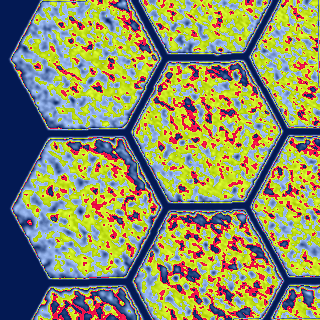

In [223]:
transforms.ToPILImage()(get_augmented_transformer(320)(img))